# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100.0%
100.0%
100.0%
100.0%


# Add Noise

In [4]:
def add_noise(images):
    noise = torch.randn_like(images) * 0.5
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

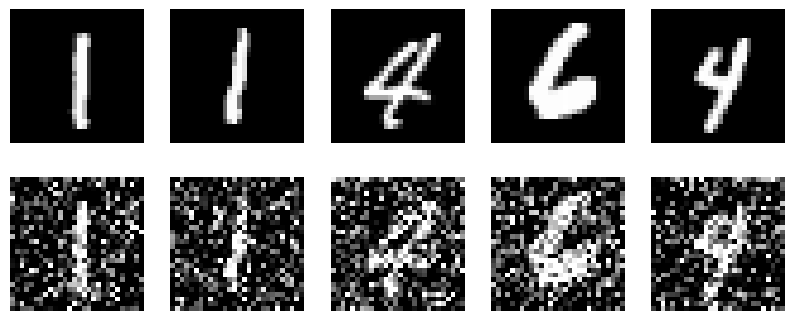

In [5]:
images, _ = next(iter(train_loader))

noisy = add_noise(images)

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

# Construct Autoencoder

In [6]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    

# Build Model

In [7]:
model = Autoencoder().to(device)

loss_function = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train

In [8]:
epochs = 20

train_losses = []

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        outputs = model(noisy_images)

        loss = loss_function(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 0.1172
Epoch 2/20, Loss: 0.1060
Epoch 3/20, Loss: 0.1059
Epoch 4/20, Loss: 0.1059
Epoch 5/20, Loss: 0.1059
Epoch 6/20, Loss: 0.0757
Epoch 7/20, Loss: 0.0144
Epoch 8/20, Loss: 0.0137
Epoch 9/20, Loss: 0.0133
Epoch 10/20, Loss: 0.0131
Epoch 11/20, Loss: 0.0130
Epoch 12/20, Loss: 0.0129
Epoch 13/20, Loss: 0.0127
Epoch 14/20, Loss: 0.0127
Epoch 15/20, Loss: 0.0126
Epoch 16/20, Loss: 0.0126
Epoch 17/20, Loss: 0.0125
Epoch 18/20, Loss: 0.0125
Epoch 19/20, Loss: 0.0124
Epoch 20/20, Loss: 0.0124


# Draw Loss

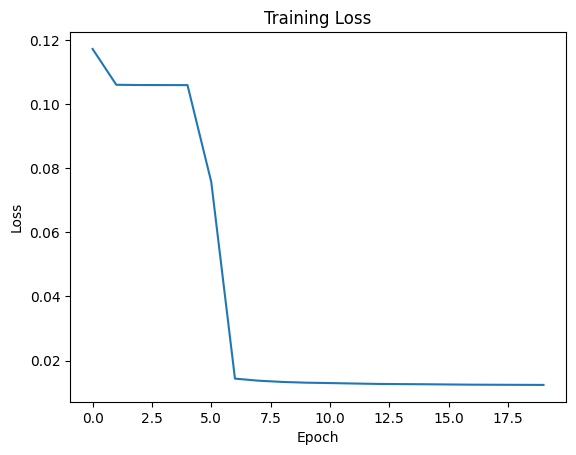

In [9]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Test Model

In [10]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))
    images = images.to(device)

    noisy_images = add_noise(images)

    outputs = model(noisy_images)

# Show Results

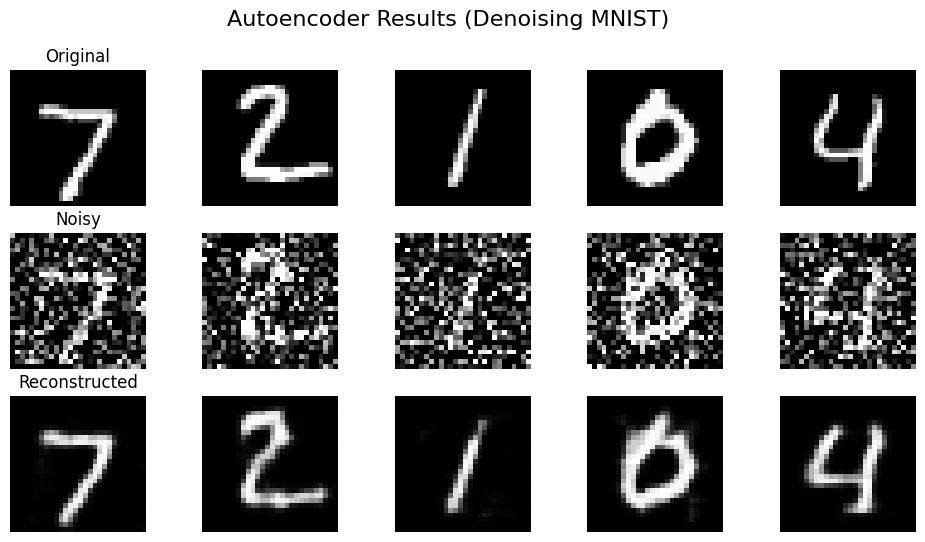

In [24]:
plt.figure(figsize=(12,6))

for i in range(5):

    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

    # Noisy
    plt.subplot(3,5,i+6)
    plt.imshow(noisy_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3,5,i+11)
    plt.imshow(outputs[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder Results (Denoising MNIST)", fontsize=16)

plt.subplot(3,5,1); plt.title("Original")
plt.subplot(3,5,6); plt.title("Noisy")
plt.subplot(3,5,11); plt.title("Reconstructed")

plt.show()

# Save Model

In [25]:
torch.save(model.state_dict(), "autoencoder.pth")
print("Model saved")

Model saved


# Load it

In [26]:
model = Autoencoder().to(device)
model.load_state_dict(torch.load("autoencoder.pth"))
model.eval()

print("Model loaded")

Model loaded
